In [27]:
# ============================================================
#  Frontera de Decision - Deteccion de Fraude en Seguros
#  PCA | t-SNE | UMAP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
import umap
import os

# ──────────────────────────────────────────────
# 1. CONFIGURACION
# ──────────────────────────────────────────────

CSV_PATH = os.path.join("..", "data", "df_final.csv")

GRID_RES  = 200             # resolucion de la malla (aumentado para mejor calidad)
N_POINTS  = 2500            # puntos a visualizar (submuestra)
TSNE_ITER = 1000            # iteraciones de t-SNE
RANDOM_STATE = 42

print(f"Cargando datos desde: {CSV_PATH}")
print(f"Ruta absoluta: {os.path.abspath(CSV_PATH)}")

Cargando datos desde: ..\data\df_final.csv
Ruta absoluta: c:\Users\Miguel Fernández\Desktop\2º CURSO\SEGUNDO SEMESTRE\Aprendizaje Automático\Trabajo_Fraudes\data\df_final.csv


In [28]:
# ──────────────────────────────────────────────
# 2. CARGA Y FEATURE ENGINEERING
# ──────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
print(f"Dataset cargado: {df.shape}")
print(f"Columnas disponibles: {df.columns.tolist()[:10]}...")
print(f"Fraud flag column: {'fraud_flag' in df.columns}")

NUM_COLS = [
    "number_of_supplements", "claimed_amount_eur", "deductible",
    "annual_premium_eur", "number_of_cars", "manufacture_year",
    "purchase_price_eur", "odometer_km", "driver_rating",
]
CAT_COLS = [
    "fault", "accident_area", "police_report_filed", "witness_present",
    "base_policy", "sex", "marital_status", "vehicle_category",
]

# Feature engineering
df["past_claims_num"] = (
    df["past_number_of_claims"]
    .map({"none": 0, "1": 1, "2": 2, "3": 3, "4": 4})
    .fillna(0)
)
df["accident_datetime"] = pd.to_datetime(df["accident_datetime"], errors="coerce")
df["claim_datetime"]    = pd.to_datetime(df["claim_datetime"],    errors="coerce")
df["days_to_claim"] = (df["claim_datetime"] - df["accident_datetime"]).dt.days

feat_df = df[NUM_COLS + ["past_claims_num", "days_to_claim"]].copy()

for col in CAT_COLS:
    le = LabelEncoder()
    feat_df[col] = le.fit_transform(df[col].fillna("Unknown").astype(str))

feat_df = feat_df.fillna(feat_df.median())

y = df["fraud_flag"].values
X = feat_df.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nDataset: {len(y):,} reclamaciones | Fraude: {y.sum():,} ({y.mean():.1%})")


Dataset cargado: (12267, 46)
Columnas disponibles: ['claim_id', 'policy_id', 'customer_id', 'vehicle_id', 'agent_id', 'accident_datetime', 'claim_datetime', 'fault', 'accident_area', 'accident_description']...
Fraud flag column: True

Dataset: 12,267 reclamaciones | Fraude: 878 (7.2%)


In [29]:
# ──────────────────────────────────────────────
# 3. PROYECCIONES
# ──────────────────────────────────────────────

np.random.seed(RANDOM_STATE)

print("Calculando PCA...")
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_
print(f"  Varianza explicada: PC1={var_exp[0]:.1%}, PC2={var_exp[1]:.1%}")

print("Calculando t-SNE (puede tardar 1-2 min)...")
tsne = TSNE(n_components=2, random_state=RANDOM_STATE,
            perplexity=30, max_iter=TSNE_ITER)
X_tsne = tsne.fit_transform(X_scaled)

print("Calculando UMAP...")
reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE,
                    n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)

print("✓ Proyecciones completadas.")


Calculando PCA...
  Varianza explicada: PC1=5.7%, PC2=5.7%
Calculando t-SNE (puede tardar 1-2 min)...
Calculando UMAP...


C:\Users\Miguel Fernández\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Proyecciones completadas.


In [30]:
# ──────────────────────────────────────────────
# 4. FRONTERA DE DECISION (RandomForest en 2D)
# ──────────────────────────────────────────────

def compute_boundary(X_2d, y, grid_res=80):
    """
    Entrena un RandomForest en el espacio 2D y devuelve
    la malla de probabilidades para dibujar la frontera.
    """
    clf = RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced"
    )
    clf.fit(X_2d, y)

    margin = 0.08
    dx = X_2d[:, 0].max() - X_2d[:, 0].min()
    dy = X_2d[:, 1].max() - X_2d[:, 1].min()
    x_min = X_2d[:, 0].min() - margin * dx
    x_max = X_2d[:, 0].max() + margin * dx
    y_min = X_2d[:, 1].min() - margin * dy
    y_max = X_2d[:, 1].max() + margin * dy

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_res),
        np.linspace(y_min, y_max, grid_res),
    )
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    score = clf.score(X_2d, y)
    return xx, yy, Z, score

print("Calculando fronteras de decision...")
xx_pca,  yy_pca,  Z_pca,  score_pca  = compute_boundary(X_pca,  y, GRID_RES)
xx_tsne, yy_tsne, Z_tsne, score_tsne = compute_boundary(X_tsne, y, GRID_RES)
xx_umap, yy_umap, Z_umap, score_umap = compute_boundary(X_umap, y, GRID_RES)
print(f"  Accuracy 2D — PCA: {score_pca:.3f} | t-SNE: {score_tsne:.3f} | UMAP: {score_umap:.3f}")


Calculando fronteras de decision...
  Accuracy 2D — PCA: 1.000 | t-SNE: 1.000 | UMAP: 1.000


C:\Users\Miguel Fernández\AppData\Local\Temp\ipykernel_20456\1814721730.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


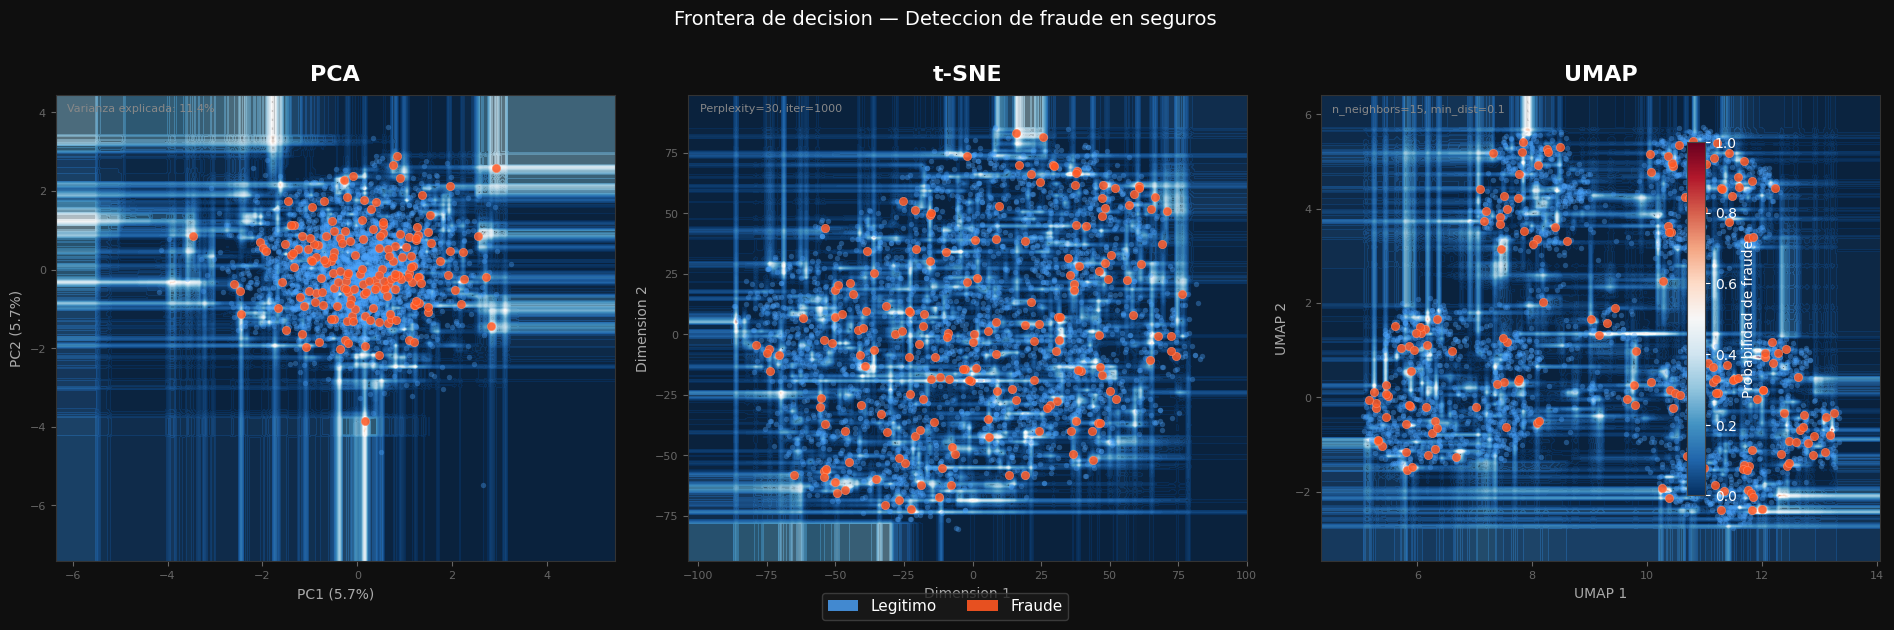

✓ Guardado como decision_boundary.png


In [31]:
# ──────────────────────────────────────────────
# 5. VISUALIZACION
# ──────────────────────────────────────────────

CMAP = plt.cm.RdBu_r          # azul = legit, rojo = fraude
ALPHA_BG   = 0.55             # transparencia del fondo
ALPHA_LEGIT = 0.35            # transparencia puntos legitimos
ALPHA_FRAUD = 0.85            # transparencia puntos fraude
SIZE_LEGIT  = 15
SIZE_FRAUD  = 35

def subsample(X_2d, y, n=N_POINTS, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(y), size=min(n, len(y)), replace=False)
    return X_2d[idx], y[idx]

configs = [
    ("PCA",   X_pca,  xx_pca,  yy_pca,  Z_pca,
     f"PC1 ({var_exp[0]:.1%})", f"PC2 ({var_exp[1]:.1%})",
     f"Varianza explicada: {(var_exp[0]+var_exp[1]):.1%}"),
    ("t-SNE", X_tsne, xx_tsne, yy_tsne, Z_tsne,
     "Dimension 1", "Dimension 2",
     "Perplexity=30, iter=1000"),
    ("UMAP",  X_umap, xx_umap, yy_umap, Z_umap,
     "UMAP 1", "UMAP 2",
     "n_neighbors=15, min_dist=0.1"),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.patch.set_facecolor("#0f0f0f")

for ax, (name, X_2d, xx, yy, Z, xlabel, ylabel, note) in zip(axes, configs):
    ax.set_facecolor("#0f0f0f")

    # fondo de probabilidad con mejor interpolación
    ax.contourf(xx, yy, Z, levels=100, cmap=CMAP, alpha=ALPHA_BG, vmin=0, vmax=1)

    # contorno de la frontera (0.5)
    ax.contour(xx, yy, Z, levels=[0.5], colors=["white"],
               linewidths=1.2, linestyles="--", alpha=0.7)

    # puntos
    Xs, ys = subsample(X_2d, y)
    mask_l = ys == 0
    mask_f = ys == 1

    ax.scatter(Xs[mask_l, 0], Xs[mask_l, 1],
               s=SIZE_LEGIT, c="#4DA6FF", alpha=ALPHA_LEGIT,
               linewidths=0, label=f"Legitimo ({mask_l.sum():,})", zorder=3)
    ax.scatter(Xs[mask_f, 0], Xs[mask_f, 1],
               s=SIZE_FRAUD, c="#FF5722", alpha=ALPHA_FRAUD,
               linewidths=0.5, edgecolors="#FF8A65",
               label=f"Fraude ({mask_f.sum():,})", zorder=4)

    ax.set_title(name, color="white", fontsize=16, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, color="#aaaaaa", fontsize=10)
    ax.set_ylabel(ylabel, color="#aaaaaa", fontsize=10)
    ax.tick_params(colors="#666666", labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")

    ax.text(0.02, 0.98, note, transform=ax.transAxes,
            color="#888888", fontsize=8, va="top")

# Leyenda compartida
legend_elements = [
    Patch(facecolor="#4DA6FF", alpha=0.8, label="Legitimo"),
    Patch(facecolor="#FF5722", alpha=0.9, label="Fraude"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2,
           frameon=True, facecolor="#1a1a1a", edgecolor="#444",
           labelcolor="white", fontsize=11, bbox_to_anchor=(0.5, -0.02))

# Barra de color
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=mcolors.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical",
                    fraction=0.012, pad=0.02, shrink=0.8)
cbar.set_label("Probabilidad de fraude", color="white", fontsize=10)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
cbar.outline.set_edgecolor("#444")

fig.suptitle(
    "Frontera de decision — Deteccion de fraude en seguros",
    color="white", fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig("decision_boundary.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("✓ Guardado como decision_boundary.png")